# Продолжаем


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"hearing_test.csv")

In [3]:
X = df.drop('test_result', axis=1)
y = df['test_result']

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)
scaler = StandardScaler()
scaler_x_train = scaler.fit_transform(X_train)
scaler_x_test = scaler.transform(X_test)

In [6]:
from sklearn.linear_model import LogisticRegression
#penalty l1, l2 - Штрафное слагаемое для регуляризации
# c - сила регуляризации

In [7]:

log_model = LogisticRegression()
log_model.fit(scaler_x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [8]:
log_model.coef_

array([[-0.95017725,  3.46148946]])

In [9]:
y_pred = log_model.predict(scaler_x_test)
y_pred

array([1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,

In [10]:
# также есть predict_proba - вероятность какого либо класса
y_pred_proba = log_model.predict_log_proba(scaler_x_train)
y_pred_proba[0:5]
# в первом вероятность класса 0, во втором вероятность класса 1

array([[-6.51562953e+00, -1.48122029e-03],
       [-7.73659387e-02, -2.59764225e+00],
       [-8.42922801e+00, -2.18413870e-04],
       [-4.35162831e-02, -3.15629933e+00],
       [-1.67579437e+00, -2.07220310e-01]])

In [11]:
y_test

1718    1
2511    1
345     0
2521    1
54      0
       ..
4770    1
188     1
3335    0
4583    0
3208    0
Name: test_result, Length: 500, dtype: int64

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [13]:
acc = accuracy_score(y_test, y_pred)
acc

0.93

In [14]:
matr = confusion_matrix(y_test, y_pred)
matr

array([[172,  21],
       [ 14, 293]])

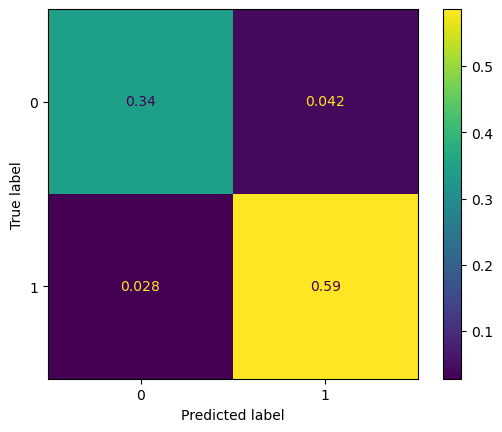

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(log_model, scaler_x_test, y_test, normalize='all')


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       193
           1       0.93      0.95      0.94       307

    accuracy                           0.93       500
   macro avg       0.93      0.92      0.93       500
weighted avg       0.93      0.93      0.93       500



In [24]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay 

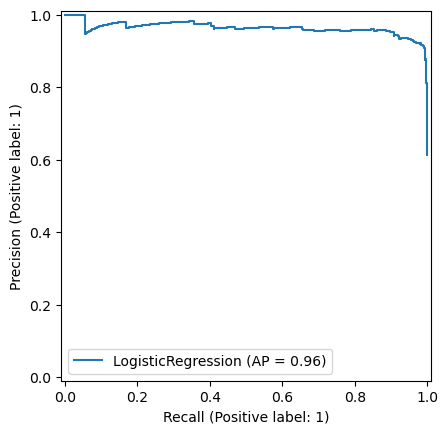

In [25]:
PrecisionRecallDisplay.from_estimator(log_model, scaler_x_test, y_test)

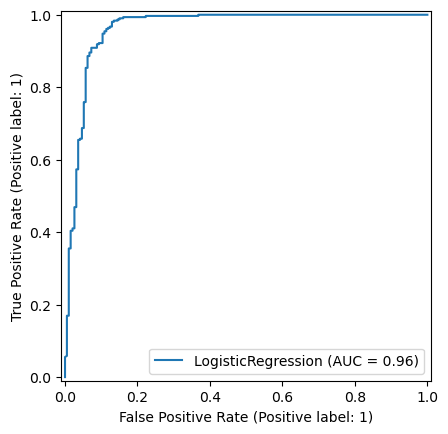

In [26]:
RocCurveDisplay.from_estimator(log_model, scaler_x_test, y_test)